# Trying to guess parameters

### Importing packages

In [1]:
%%capture
%pip install numpy matplotlib statsmodels arch

In [2]:
import numpy as np, matplotlib.pyplot as plt, statsmodels.api as sm
from arch import arch_model 

### Inputs

In [3]:
N = 10_000
P = [[0.98, 0.02], [0.05, 0.95]]

mu = [0.0, 0.0]
phi = [0.9, 0.2]
sig = [0.1, 1.5] 

### Generating data

In [4]:
s, y = [0], [0.]

for t in range(1, N+1):
    s.append(np.random.choice([0, 1], p=P[s[-1]]))
    y.append(mu[s[-1]] + phi[s[-1]] * y[-1] + np.random.normal(0, sig[s[-1]]))

y_train, y_test = np.array(y[:-1]), y[-1]

### Plotting

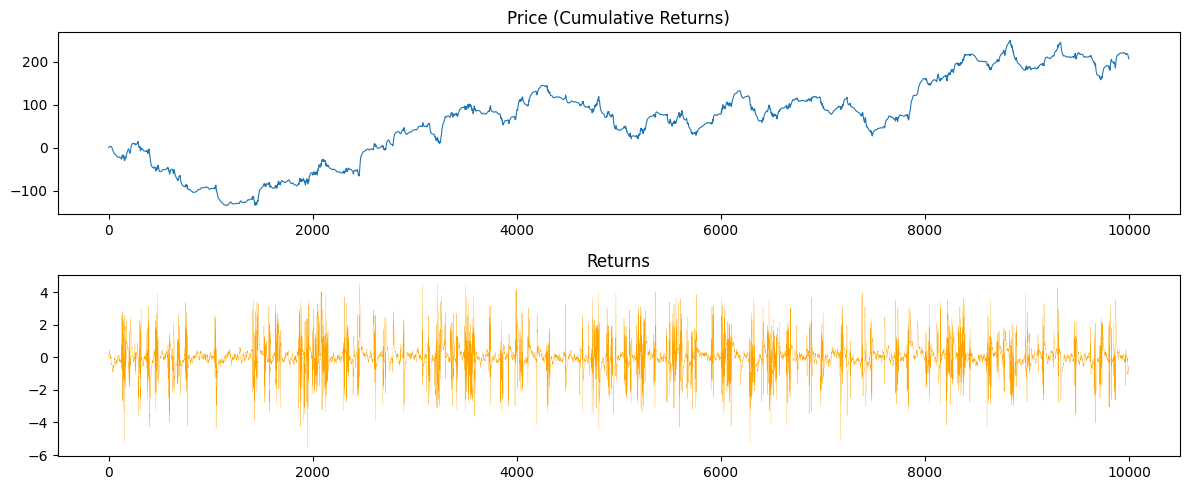

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(211)
plt.plot(np.cumsum(y_train), lw=0.8)
plt.title("Price (Cumulative Returns)")

plt.subplot(212)
plt.plot(y_train, lw=0.2, color='orange')
plt.title("Returns")

plt.tight_layout()
plt.show()

### AR(1)

In [6]:
ar = sm.tsa.AutoReg(y_train, 1).fit()
ar_mu = ar.predict(start=N, end=N)[0]
ar_var = ar.sigma2

print(f"ar : {ar}\nar_mu : {ar_mu:.6f}\nar_var : {ar_var:.6f}")

ar : <statsmodels.tsa.ar_model.AutoRegResultsWrapper object at 0x7e594a6d9dc0>
ar_mu : -0.169026
ar_var : 0.737311


### MS-AR

In [7]:
ms = sm.tsa.MarkovAutoregression(y_train, k_regimes=2, order=1, switching_variance=True).fit(disp=False)

# Force everything to flat numpy arrays
# regime_transition is (k, k, 1) in recent statsmodels; squeeze to (k, k) for matmul
trans = np.asarray(ms.regime_transition).squeeze()
filt = np.asarray(ms.filtered_marginal_probabilities)[-1].flatten() # Shape (2,)
params = np.asarray(ms.params)

# 1. Predict next state probabilities
p_next = trans @ filt

# 2. Extract params (Regime 0 then Regime 1)
# Standard MS-AR param order: [p0->0, p1->0, const.0, const.1, ar.L1.0, ar.L1.1, sigma2.0, sigma2.1]
c = params[2:4]
a = params[4:6]
v = params[6:8]

# 3. Forecast Mean and Variance
ms_mu = np.dot(p_next, c + a * y_train[-1])
ms_var = np.dot(p_next, v)

print(f"Pred Mean: {ms_mu:.6f} | Pred Var: {ms_var:.6f}")

Pred Mean: -0.024306 | Pred Var: 0.884930


### Summary

In [8]:
def winkler(y, m, v, a=0.05):
    d = 1.96 * np.sqrt(v) 
    l = m-d
    u = m+d
    return (u-l) + 2/a*max(l-y, 0) + 2/a*max(y-u, 0)

print(f"--- PREDICTION ERRORS ---\nAR(1) Winkler: {winkler(y_test, ar_mu, ar_var):.4f}")
print(f"MSAR  Winkler: {winkler(y_test, ms_mu, ms_var):.4f}")
print("\n--- MSAR RECOVERED TRANSITION MATRIX ---")
print(np.asarray(ms.regime_transition).squeeze().round(3))
print("\n--- MODEL SUMMARY ---")
print(ms.summary().tables[1])

--- PREDICTION ERRORS ---
AR(1) Winkler: 3.3660
MSAR  Winkler: 3.6876

--- MSAR RECOVERED TRANSITION MATRIX ---
[[0.979 0.053]
 [0.021 0.947]]

--- MODEL SUMMARY ---
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0068      0.011      0.605      0.545      -0.015       0.029
sigma2         0.0096      0.000     59.002      0.000       0.009       0.010
ar.L1          0.9015      0.002    411.559      0.000       0.897       0.906


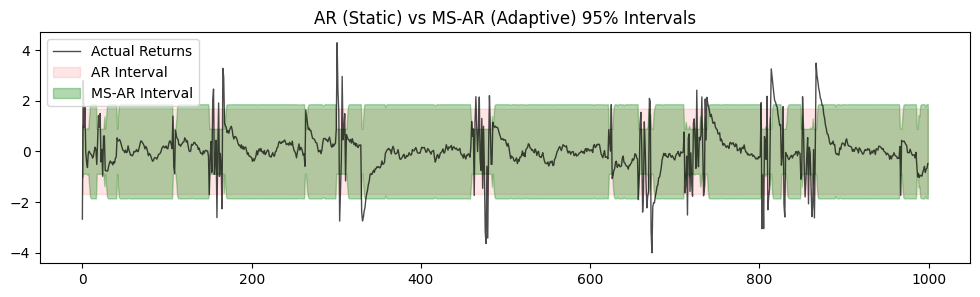

In [9]:
tail = 1000
view_y = y_train[-tail:]

# AR Interval (Centered at 0 for return volatility visualization)
ar_int = 1.96 * np.sqrt(ar_var)

# MS-AR Interval: Dot product of filtered probs and regime variances
f_probs = np.asarray(ms.filtered_marginal_probabilities)
regime_vars = np.asarray(ms.params[6:8])
ms_int = 1.96 * np.sqrt(f_probs @ regime_vars)[-tail:]

plt.figure(figsize=(12, 3))
plt.plot(view_y, color='black', lw=1, label='Actual Returns', alpha=0.7)

# Static AR band vs Dynamic MS-AR band
plt.fill_between(range(tail), -ar_int, ar_int, color='red', alpha=0.1, label='AR Interval')
plt.fill_between(range(tail), -ms_int, ms_int, color='green', alpha=0.3, label='MS-AR Interval')

plt.title("AR (Static) vs MS-AR (Adaptive) 95% Intervals")
plt.legend(loc='upper left'); plt.show()

### Adding ARCH and GARCH

In [10]:
# 1. ARCH(1) & GARCH(1,1)
am, gm = arch_model(y_train, vol='ARCH', p=1).fit(disp='off'), arch_model(y_train, vol='Garch', p=1, q=1).fit(disp='off')

# 2. MS-ARCH Proxy (Switching Variance Only)
ms_v = sm.tsa.MarkovRegression(y_train, k_regimes=2, switching_variance=True).fit(disp=False)

# FORCE SHAPES: Matrix (2,2) @ Vector (2,1) then flatten to (2,)
trans = np.asarray(ms_v.regime_transition).reshape(2, 2)
filt = np.asarray(ms_v.filtered_marginal_probabilities)[-1].reshape(2, 1)
v_p = (trans @ filt).flatten()

# Indexing MS-ARCH: [p00, p10, const, sigma2_0, sigma2_1]
msv_mu, msv_var = ms_v.params[2], np.dot(v_p, ms_v.params[3:5])

# 3. Print Summary
res = {
    "AR(1)": winkler(y_test, ar_mu, ar_var),
    "ARCH(1)": winkler(y_test, am.forecast(horizon=1).mean.values[-1,0], am.forecast(horizon=1).variance.values[-1,0]),
    "GARCH(1,1)": winkler(y_test, gm.forecast(horizon=1).mean.values[-1,0], gm.forecast(horizon=1).variance.values[-1,0]),
    "MS-AR": winkler(y_test, ms_mu, ms_var),
    "MS-ARCH": winkler(y_test, msv_mu, msv_var)
}
for k, v in sorted(res.items(), key=lambda x: x[1]): print(f"{k:<12} | Winkler: {v:.4f}")

MS-ARCH      | Winkler: 1.0339
GARCH(1,1)   | Winkler: 2.6978
ARCH(1)      | Winkler: 2.8171
AR(1)        | Winkler: 3.3660
MS-AR        | Winkler: 3.6876


### Plotting

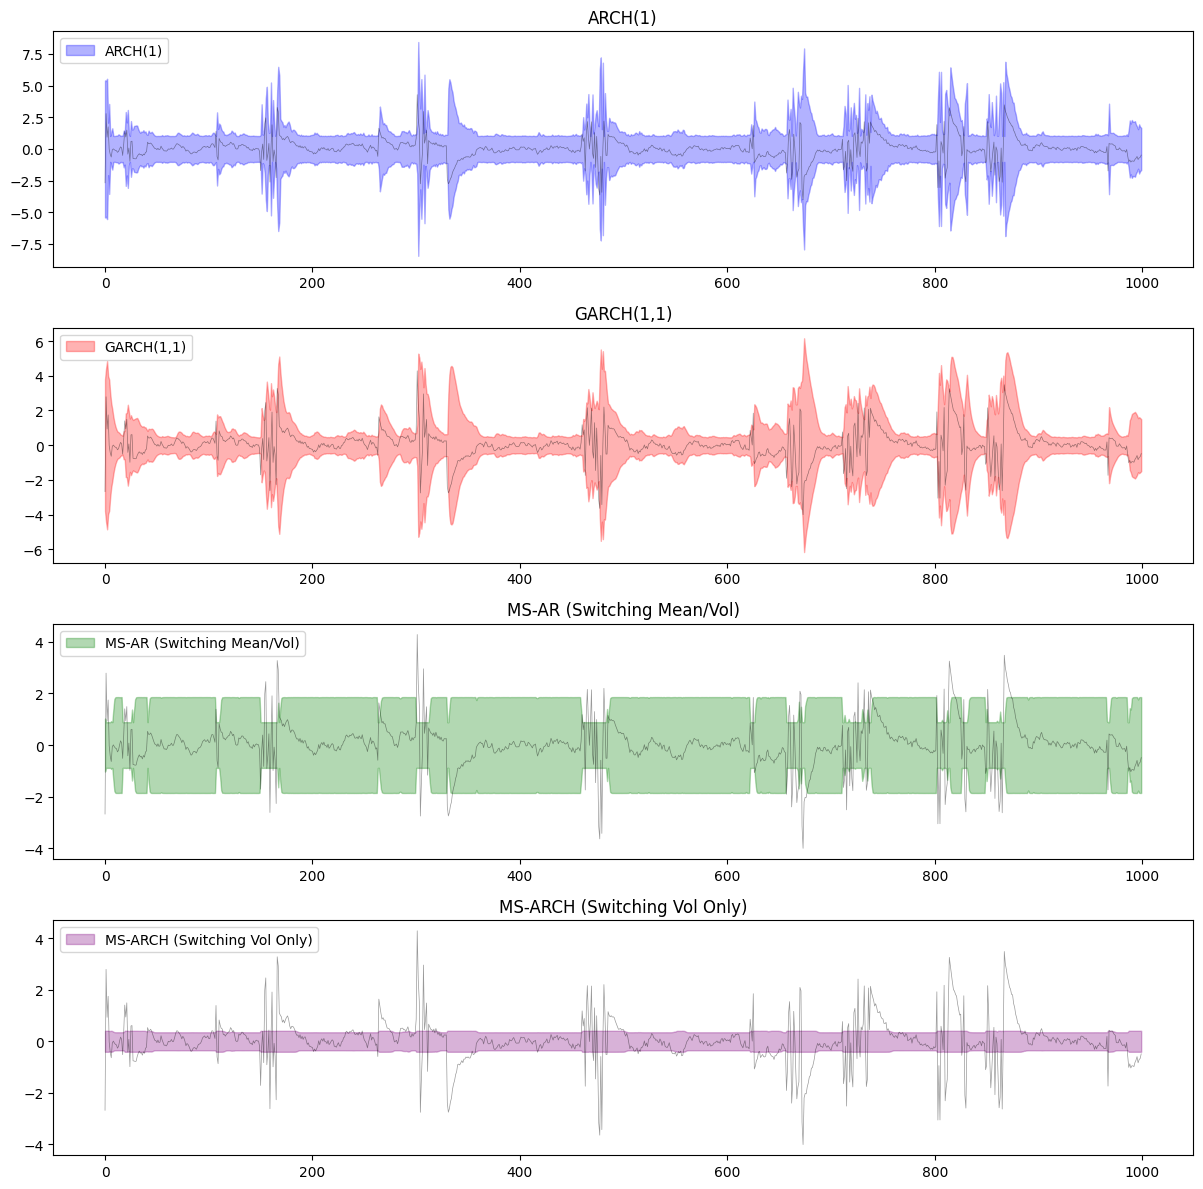

In [11]:
tail = 1000
v_y, x = y_train[-tail:], range(tail)

# Intervals (1.96 * sigma)
b_arch = 1.96 * am.conditional_volatility[-tail:]
b_garch = 1.96 * gm.conditional_volatility[-tail:]

# MS-AR Band (params[6:8])
msar_f = np.asarray(ms.filtered_marginal_probabilities)
b_msar = 1.96 * np.sqrt(msar_f @ np.asarray(ms.params[6:8]))[-tail:]

# MS-ARCH Band (params[3:5])
msv_f = np.asarray(ms_v.filtered_marginal_probabilities)
b_msv = 1.96 * np.sqrt(msv_f @ np.asarray(ms_v.params[3:5]))[-tail:]

plt.figure(figsize=(12, 12))
panels = [(411, b_arch, 'blue', 'ARCH(1)'), (412, b_garch, 'red', 'GARCH(1,1)'), 
          (413, b_msar, 'green', 'MS-AR (Switching Mean/Vol)'), (414, b_msv, 'purple', 'MS-ARCH (Switching Vol Only)')]

for idx, band, col, lbl in panels:
    ax = plt.subplot(idx)
    ax.plot(v_y, color='black', lw=0.5, alpha=0.4)
    ax.fill_between(x, -band, band, color=col, alpha=0.3, label=lbl)
    ax.set_title(lbl); ax.legend(loc='upper left')

plt.tight_layout(); plt.show()

### Summary

In [12]:
import warnings
warnings.filterwarnings("ignore") 

window = 200 
# Store: [actual, pred, var] for each model
history = {"AR(1)": [], "ARCH(1)": [], "GARCH(1,1)": [], "MS-AR": []}
actuals = []

print(f"Backtesting {window} iterations...")
for i in range(window, 0, -1):
    idx = -i if i > 1 else None
    train, actual = y_train[:idx], (y_train[idx] if idx else y_test)
    actuals.append(actual)
    
    try:
        # 1. AR(1)
        m = sm.tsa.AutoReg(train, 1).fit()
        history["AR(1)"].append([m.predict(len(train), len(train))[0], m.sigma2])
        
        # 2. ARCH & GARCH
        for n, p, q in [("ARCH(1)", 1, 0), ("GARCH(1,1)", 1, 1)]:
            res = arch_model(train, vol='Garch' if q > 0 else 'ARCH', p=p, q=q).fit(disp='off')
            f = res.forecast(horizon=1)
            history[n].append([f.mean.values[-1,0], f.variance.values[-1,0]])
            
        # 3. MS-AR
        m_ms = sm.tsa.MarkovAutoregression(train, 2, 1, switching_variance=True).fit(disp=False)
        p_nxt = np.asarray(m_ms.regime_transition).reshape(2, 2) @ np.asarray(m_ms.filtered_marginal_probabilities)[-1].flatten()
        pars = np.asarray(m_ms.params)
        history["MS-AR"].append([np.dot(p_nxt, pars[2:4] + pars[4:6] * train[-1]), np.dot(p_nxt, pars[6:8])])
    except: continue

print("Done.")

Backtesting 200 iterations...
Done.


In [13]:
def analyze(name, y, p, v):
    y, p, v, s = np.array(y), np.array(p), np.array(v), np.sqrt(v)
    # Stats
    mse, mae = np.mean((y-p)**2), np.mean(np.abs(y-p))
    wink = np.mean([(u-l) + 40*max(l-val, 0) + 40*max(val-u, 0) for val, m, sd in zip(y, p, s) for l, u in [(m-1.96*sd, m+1.96*sd)]])
    cov = np.mean((y >= p - 1.96*s) & (y <= p + 1.96*s))
    bias = np.mean(y - p)
    # Finance (Assume strategy: go long if pred > 0, short if pred < 0)
    rets = np.sign(p) * y
    sharpe = np.mean(rets) / np.std(rets) * np.sqrt(252)
    hit = np.mean(np.sign(y) == np.sign(p))
    var_viol = np.mean(y < (p - 1.645 * s)) # 95% VaR violations
    total_ret = np.sum(rets)
    max_dd = np.max(np.maximum.accumulate(np.cumsum(rets)) - np.cumsum(rets))
    
    return [mse, mae, wink, cov, bias, sharpe, hit, var_viol, total_ret, max_dd]

headers = ["MSE", "MAE", "Winkler", "Cov95", "Bias", "Sharpe", "HitRate", "VaR_V", "TotRet", "MaxDD"]
print(f"{'Model':<12} | " + " | ".join(f"{h:<7}" for h in headers))
print("-" * 110)

for mod in history:
    data = np.array(history[mod])
    m = analyze(mod, actuals[:len(data)], data[:,0], data[:,1])
    print(f"{mod:<12} | " + " | ".join(f"{x:<7.3f}" for x in m))

Model        | MSE     | MAE     | Winkler | Cov95   | Bias    | Sharpe  | HitRate | VaR_V   | TotRet  | MaxDD  
--------------------------------------------------------------------------------------------------------------
AR(1)        | 0.802   | 0.525   | 5.921   | 0.905   | 0.044   | 5.990   | 0.775   | 0.050   | 74.644  | 6.061  
ARCH(1)      | 1.116   | 0.657   | 5.696   | 0.935   | 0.081   | 1.381   | 0.505   | 0.040   | 18.327  | 20.126 
GARCH(1,1)   | 1.117   | 0.656   | 4.303   | 0.940   | 0.086   | 1.381   | 0.505   | 0.045   | 18.327  | 20.126 
MS-AR        | 2.931   | 0.913   | 20.355  | 0.795   | 0.249   | 5.486   | 0.725   | 0.070   | 69.055  | 6.061  
